## Lab Practice Genetic Algorithms 1.1:  BASICS (classwork)  | Machine Learning II
#### ESU  Jan-2025
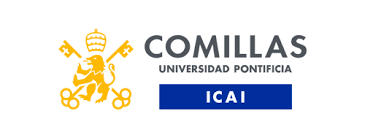

LEARNING OBJECTIVES
- How to run ga in a simple maximization problem
- How to interpret the obtained results

---
## Import modules

In [1]:
import numpy as np # linear algebra
import pandas as pd  # data management
import matplotlib.pyplot as plt
import seaborn as sns  # plotting

import pygad  # genetic algorithms
from IPython.display import clear_output

---
##  1. Maximization problem

### 1.1 Problem definition

Find the value of x in the range $-30 <= x <= 30 $ that maximizes the function:

$f(x) = (x^2 + x) * cos(x) * sin(x/2)$ 

In [2]:
# function to be maximized (the fitness)
min_val = -30
max_val = 30

#### Lo primero que tenemos que hacer es definir la funcion de fitness.

def fitness_func(ga_instance, solution, solution_idx):
    
    fitness = (solution**2 + solution) * np.cos(solution) * np.sin(solution/2)

    # print(fitness)
    if isinstance(fitness, np.ndarray):
        if fitness.size == 1:
            fitness = fitness[0]
    
    return fitness

### 1.2 show the problem

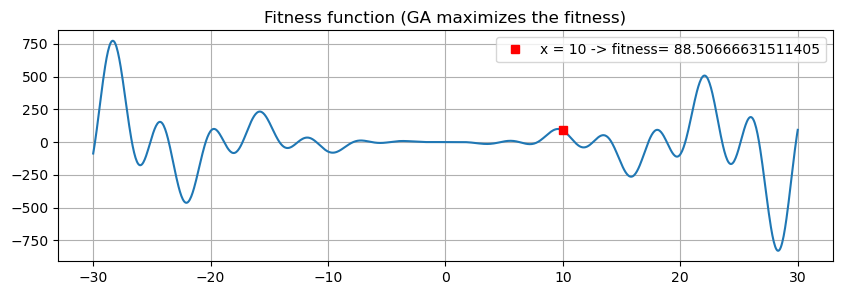

In [3]:
fig = plt.figure(figsize=(10,3))
xs = np.linspace(min_val, max_val, 1000)
plt.plot(xs, fitness_func([], xs, 0))
plt.plot(10, fitness_func([], 10, 0), 'sr', label = f'x = 10 -> fitness= {fitness_func([], 10, 0)}')
plt.legend()
plt.title('Fitness function (GA maximizes the fitness)')
plt.grid()
plt.show()

In [4]:
fitness_function = fitness_func

num_generations = 50

sol_per_pop = 150
num_genes = 1
gene_space = {'low': -30, 'high': 30}

init_range_low = -30.0
init_range_high = 30.0

num_parents_mating = sol_per_pop - 10
crossover_probability = 0.9

mutation_probability  = 0.1
random_mutation_min_val= -5.0
random_mutation_max_val= 5.0

# sss (for steady-state selection), rws (for roulette wheel selection)
parent_selection_type = "sss"
keep_parents = 2

crossover_type = "single_point"

mutation_type = "random"

# reach a max fitness value and stop after a nº of generations max constant fitness
stop_criteria=["reach_1000", "saturate_15"]

keep_elitism = 2

In [5]:
# For monitoring the evolution of the indiviuals

xs = np.linspace(min_val, max_val, 1000)

def on_generation(ga):

    solution, solution_fitness, solution_idx = ga.best_solution()

    clear_output(wait=True)
    #(np.ceil(num_generations/4), 4, ga.generations_completed)
    plt.plot(xs, fitness_func(ga, xs, 0))
    plt.plot(ga.population, fitness_func(ga, ga.population, np.zeros(ga.population.size)), '.k')
    plt.plot(ga.population, -800 * np.ones(ga.population.shape), '.k')

    plt.plot(solution, solution_fitness, 'sr', label = 'best')

    plt.title(f'Generation {ga.generations_completed} / {ga.num_generations} || best =({solution}, {solution_fitness})')
    plt.legend()
    plt.grid()
    plt.show()
    return

In [6]:
# set the ga

### Llamada al genetico y parametros que se le pasan
ga_instance = pygad.GA(num_generations=num_generations,  ######### Número de generaciones
                       num_parents_mating=num_parents_mating, ######## Probabilidad de cruce alta y probabilidad de mutacion baja.
                       fitness_func=fitness_function,
                       sol_per_pop=sol_per_pop,
                       num_genes=num_genes,
                       gene_space = gene_space,
                       crossover_probability = crossover_probability,
                       mutation_probability  = mutation_probability,
                       random_mutation_min_val= random_mutation_min_val,
                       random_mutation_max_val = random_mutation_max_val,
                       init_range_low=init_range_low,
                       init_range_high=init_range_high,
                       parent_selection_type=parent_selection_type,
                       keep_parents=keep_parents,
                       crossover_type=crossover_type,
                       mutation_type=mutation_type,
                       stop_criteria=stop_criteria,
                       keep_elitism=keep_elitism,
                       random_seed=2,
                       save_solutions=True,
                       on_generation=on_generation,
                       )


/Applications/anaconda3/envs/ML2-GA-2025/lib/python3.11/site-packages/pygad/pygad.py:1145: UserWarning: Use the 'save_solutions' parameter with caution as it may cause memory overflow when either the number of generations, number of genes, or number of solutions in population is large.
  warnings.warn("Use the 'save_solutions' parameter with caution as it may cause memory overflow when either the number of generations, number of genes, or number of solutions in population is large.")


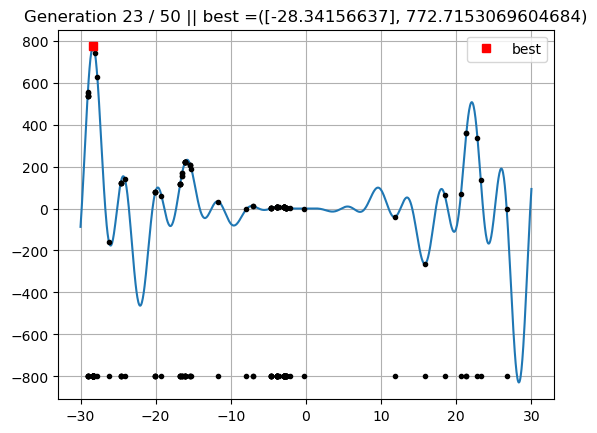

In [7]:
# run the ga
ga_instance.run()

/Applications/anaconda3/envs/ML2-GA-2025/lib/python3.11/site-packages/pygad/visualize/plot.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  matplt.legend()


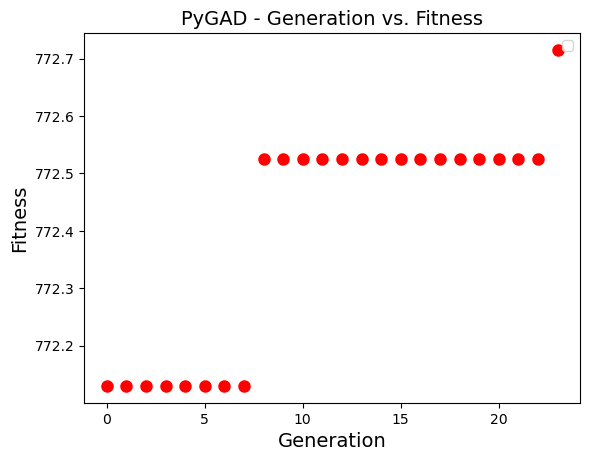

Parameters of the best solution : [-28.34156637]
Fitness value of the best solution = 772.7153069604684
Index of the best solution : 35


In [8]:
#ga_instance.plot_genes()
ga_instance.plot_fitness(plot_type = 'scatter', color='red')

# Returning the details of the best solution.
solution, solution_fitness, solution_idx = ga_instance.best_solution(ga_instance.last_generation_fitness)
print(f"Parameters of the best solution : {solution}")
print(f"Fitness value of the best solution = {solution_fitness}")
print(f"Index of the best solution : {solution_idx}")